# **Exploratory Data Analysis (EDA) on Long-Term VM Candidates**

## **Notebook Objective**
This notebook aims to perform **Exploratory Data Analysis (EDA)** on the extracted **long-term Virtual Machine (VM) candidates** to understand the distribution, rate, and percentage of usage of the `vm_category` column present in the `vmtable.csv` dataset.

## **Dataset Source**
The dataset `vmtable.csv` has been provided by the data provider and is available in their **GitHub repository**.

## **Key Analysis Steps**
- Load and explore the dataset.
- Perform data cleaning and preprocessing if necessary.
- Analyze the distribution of `vm_category`.
- Compute and visualize the rate and percentage of each category.
- Identify patterns or trends in long-term VM usage.

## **Tools & Libraries Used**
- **Polars** for **fast** read and data manipulation over large data using `df.lazy()`.
- **Matplotlib & Seaborn** for visualization.
- **NumPy** for numerical computations.

## **Expected Outcome**
This analysis will help in understanding how different VM categories are utilized over the long term, providing insights for potential optimizations or forecasting.

---

📌 **Note:** If any additional data preprocessing or specific analysis is required, modifications can be made accordingly.

---

### **Dataset Characteristics**

<center>

$\#$ public dataset | Year of Azure VM workload collection | Duration | Total #VMs | Time-resolution/epoch | Dataset size
---|:---:|:-----:|:---:|:---:|:---:
#1 [MS Azure cloud VM CPU Usage](https://github.com/amcs1729/Predicting-cloud-CPU-usage-on-Azure-data/blob/master/README.md)  | [Jan 2017](https://github.com/amcs1729/Predicting-cloud-CPU-usage-on-Azure-data?tab=readme-ov-file) | 30 consecutive days | 1 | 5-minute VM CPU utilization readings |  633KB (csv) [1 file]
#2 [AzurePublicDatasetV1](https://github.com/Azure/AzurePublicDataset/blob/master/AzurePublicDatasetV1.md) | [2017](https://github.com/Azure/AzurePublicDataset/tree/master) | maximum 30 consecutive days | 2,013,767 (~2M) | 5-minute VM CPU utilization readings (encrypted) |  117GB (78.5GB compressed) [128 files]
#3 [AzurePublicDatasetV2](https://github.com/Azure/AzurePublicDataset/blob/master/AzurePublicDatasetV2.md)  | [2019](https://github.com/Azure/AzurePublicDataset/tree/master) | maximum 30 consecutive days | 2,695,548 (~2.6M) | 5-minute VM CPU utilization readings (encrypted) |  235GB (156GB compressed) [198 files]

</center>

---


In [ ]:
import polars as pl
import glob
import os
import re

#import warnings
#warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
import pandas as pd
pd.__version__    #'2.0.3'

'2.1.4'

In [ ]:
#!pip install pandas==2.1.4

In [ ]:
def sanitize_filename(vmid):
    return re.sub(r'[<>:"/\\|?*]', '_', vmid)

In [ ]:
%%time
# Define output directory
output_dir = "/home/mehryar/interested_vmid_list_V1"
os.makedirs(output_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Search for all csv.gz files in the folder
path = "/home/mehryar/vm_cpu_readings_V1/data/*.csv.gz"
files = glob.glob(path)

lazy_dfs = []

column_names = ['timestamp', 'vmid', 'mincpu', 'maxcpu', 'avgcpu']

for file in files:
    df = pl.read_csv(file, has_header=False, new_columns=column_names)
    lazy_df = df.lazy()
    lazy_dfs.append(lazy_df)
    print(f'Read: {file}')

# Combine all dataframes into a single dataframe
combined_lazy_df = pl.concat(lazy_dfs)

Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-85-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-36-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-93-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-46-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-7-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-18-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-96-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-91-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-113-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-5-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-33-of-125.csv.gz
Read: /home/mehryar/vm_cpu_readings_V1/data/vm_cpu_readings-file-71-of-125.csv.gz
Read: /home/mehry

In [ ]:
#print("Combined Columns:", combined_lazy_df.columns)
print("Combined Columns:", combined_lazy_df.collect_schema().names())

Combined Columns: ['timestamp', 'vmid', 'mincpu', 'maxcpu', 'avgcpu']


In [ ]:
%%time
new_column_names = column_names

if len(combined_lazy_df.collect_schema().names()) == len(new_column_names):
    combined_lazy_df = combined_lazy_df.rename(
        {old_name: new_name for old_name, new_name in zip(combined_lazy_df.collect_schema().names(), new_column_names)}
    )

if all(col in combined_lazy_df.collect_schema().names() for col in ['timestamp', 'vmid', 'mincpu', 'maxcpu', 'avgcpu']):
    # Get the count of rows for each vmid
    vmid_counts = combined_lazy_df.group_by("vmid").count().collect()
    # print(vmid_counts)
    # Filter vmids with more than 8064 rows
    #valid_vmids = vmid_counts.filter(pl.col("count") > 88)["vmid"].to_list()      #20*288
    valid_vmids = vmid_counts.filter(pl.col("count") >= 8352)["vmid"].to_list()      #29*288=8352  pl.col("count") ---> pl.col("len")
    print("Unique VMIDs contain 8352 rows:", len(valid_vmids))                     #179,393

    # Convert the valid_vmids list to a DataFrame
    valid_vmids_df = pl.DataFrame({"vmid": valid_vmids})
    # Define the name of the output file
    output_file = os.path.join(output_dir, "valid_vmids_V1.csv")
    # Save DataFrame as CSV
    valid_vmids_df.write_csv(output_file)

    print(f"Valid VMIDs have been saved to: {output_file}")

<timed exec>:10: DeprecationWarning: `LazyGroupBy.count` is deprecated. It has been renamed to `len`.


Unique VMIDs contain 8352 rows: 103230
Valid VMIDs have been saved to: /home/mehryar/interested_vmid_list_V1/valid_vmids_V1.csv
CPU times: user 16min 42s, sys: 11min 21s, total: 28min 3s
Wall time: 1min 53s


In [ ]:
valid_vmids_df

vmid
str
"""MY8Po3SvoM/Z2Wri5fiGZJyxtUyFr3…"
"""xctM4rlIXF74X7gUkFwJIpngVGP3BG…"
"""saDN+uX+oSPgX7L9iauzw3DIUuTZsI…"
"""LQ+3FeaGThJM47HoQimKbG1qp0WnUN…"
"""Y1cThA2YSXYE/pklLegD7ZROXAOsV6…"
…
"""pSMKuoBSJpjfBdnTAJvq81O2VCd75s…"
"""KejZ2J+PogD0zpz32iAErDOBVWKj+7…"
"""cem1WYALDeRxiCXf0LdLqEKmxN5LJr…"


In [ ]:
# 1. Load the valid_vmids.csv file
valid_vmids_df = pl.read_csv(os.path.join(output_dir, "/home/mehryar/interested_vmid_list_V1/valid_vmids_V1.csv"))
valid_vmids_df

vmid
str
"""MY8Po3SvoM/Z2Wri5fiGZJyxtUyFr3…"
"""xctM4rlIXF74X7gUkFwJIpngVGP3BG…"
"""saDN+uX+oSPgX7L9iauzw3DIUuTZsI…"
"""LQ+3FeaGThJM47HoQimKbG1qp0WnUN…"
"""Y1cThA2YSXYE/pklLegD7ZROXAOsV6…"
…
"""pSMKuoBSJpjfBdnTAJvq81O2VCd75s…"
"""KejZ2J+PogD0zpz32iAErDOBVWKj+7…"
"""cem1WYALDeRxiCXf0LdLqEKmxN5LJr…"


In [ ]:
%%time

# 1. Load the valid_vmids.csv file
valid_vmids_df = pl.read_csv(os.path.join(output_dir, "/home/mehryar/interested_vmid_list_V1/valid_vmids_V1.csv"))

# 2. Load the vmtable.csv.gz file
data_path = '/home/mehryar/vm_cpu_readings_V1/misc/vmtable.csv.gz'
headers = ['vmid', 'subscriptionid', 'deploymentid', 'vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu',
           'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']

# Specify dtypes
dtypes = {
    'vmid': pl.Utf8,
    'subscriptionid': pl.Utf8,
    'deploymentid': pl.Utf8,
    'vmcreated': pl.Int64,
    'vmdeleted': pl.Int64,
    'maxcpu': pl.Float64,
    'avgcpu': pl.Float64,
    'p95maxcpu': pl.Float64,
    'vmcategory': pl.Utf8,
    'vmcorecountbucket': pl.Int64,
    'vmmemorybucket': pl.Int64
}

vmtable_df = pl.read_csv(
    data_path,
    has_header=False,
    new_columns=headers,
    dtypes=dtypes,
    ignore_errors=True,
    null_values=['>24'],
    try_parse_dates=True
)

# 3. Combine the data and create a new CSV file
trace_dataframe = (valid_vmids_df
             .join(vmtable_df.select(vmtable_df.columns), on='vmid', how='left')
             .sort('vmid'))

# Save the result as a CSV file
result_csv_path = os.path.join(output_dir, "vmtable_filtered_V1.csv")
trace_dataframe.write_csv(result_csv_path)
print(f"Results saved to: {result_csv_path}")


<timed exec>:24: DeprecationWarning: The argument `dtypes` for `read_csv` is deprecated. It has been renamed to `schema_overrides`.


Results saved to: /home/mehryar/interested_vmid_list_V1/vmtable_filtered_V1.csv
CPU times: user 7.81 s, sys: 2.55 s, total: 10.4 s
Wall time: 2.08 s


In [ ]:
vmtable_df

vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket
str,str,str,i64,i64,f64,f64,f64,str,i64,i64
"""x/XsOfHO4ocsV99i4NluqKDuxctW2M…","""VDU4C8cqdr+ORcqquwMRcsBA2l0SC6…","""Pc2VLB8aDxK2DCC96itq4vW/zVDp4w…",0,2591700,99.369869,3.424094,10.194309,"""Delay-insensitive""",1,null
"""H5CxmMoVcZSpjgGbohnVA3R+7uCTe/…","""BSXOcywx8pUU0DueDo6UMol1YzR6tn…","""3J17LcV4gXjFat62qhVFRfoiWArHnY…",0,1539300,100.0,6.181784,33.98136,"""Interactive""",1,null
"""wR/G1YUjpMP4zUbxGM/XJNhYS8cAK3…","""VDU4C8cqdr+ORcqquwMRcsBA2l0SC6…","""Pc2VLB8aDxK2DCC96itq4vW/zVDp4w…",2188800,2591700,99.569027,3.573635,7.92425,"""Delay-insensitive""",1,null
"""1XiU+KpvIa3T1XP8kk3ZY71Of03+og…","""8u+M3WcFp8pq183WoMB79PhK7xUzba…","""DHbeI+pYTYFjH8JAF8SewM0z/4SqQc…",0,2591700,99.405085,16.287611,95.69789,"""Delay-insensitive""",8,56
"""z5i2HiSaz6ZdLR6PXdnDjGva3jIlkM…","""VDU4C8cqdr+ORcqquwMRcsBA2l0SC6…","""Pc2VLB8aDxK2DCC96itq4vW/zVDp4w…",0,2188500,98.967961,3.036038,9.445484,"""Delay-insensitive""",1,null
…,…,…,…,…,…,…,…,…,…,…
"""MFGSZRXj8oVpSHz8Tt8Um+XymbdZLJ…","""3KYB4oZzTGz1Kjr8DX8pqMZLgmbsH4…","""fYha54PSPDfjrdfBxH5tFmCtCT+IIN…",1037700,1096800,82.058417,2.492943,28.357228,"""Unkown""",4,7
"""MoaiaXcKdv5SjaGMAWYvkWGsaVrBxc…","""3KYB4oZzTGz1Kjr8DX8pqMZLgmbsH4…","""fYha54PSPDfjrdfBxH5tFmCtCT+IIN…",1037700,1096800,87.61161,2.484453,20.905861,"""Unkown""",4,7
"""1UHZb9fC7yztxXgW4DP/Mnmco/krJr…","""qmftcYuQnjoTysaaE0UGTDh+KioEXT…","""8VEV+1xHOwGOUTmt4MohluwLOR4L3/…",0,2591700,95.77773,3.045443,16.36313,"""Delay-insensitive""",2,null


In [ ]:
vmtable_df.columns

['vmid',
 'subscriptionid',
 'deploymentid',
 'vmcreated',
 'vmdeleted',
 'maxcpu',
 'avgcpu',
 'p95maxcpu',
 'vmcategory',
 'vmcorecountbucket',
 'vmmemorybucket']

In [ ]:
(valid_vmids_df.shape[0]/vmtable_df.shape[0])*100

5.126213707941385

In [ ]:
(179393/2695548 )*100

6.655158802588565

In [ ]:
trace_dataframe

vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket
str,str,str,i64,i64,f64,f64,f64,str,i64,i64
"""++3x/X632+RBxrMiCXl0hgaM8HbCIz…","""tEzBxmNCl4CEVKgIW4OpnFvtsJ8qVh…","""8zzjxbXSe5oixNux26V/oHegfPpnvy…",0,2591700,99.044858,9.669272,22.660945,"""Delay-insensitive""",1,null
"""++6f+PhobyB4y2TT3ZsBulQFjoEBi+…","""rEXUJ9TtpPUqFV3Y7aKJkXl6hXUtJS…","""kraJV/DZwt3QnJTMy/8BpauYqYxMWf…",0,2591700,99.441358,4.570521,20.872346,"""Delay-insensitive""",2,null
"""++Emh319MDIxnjd5HCgcf8/EEw4Tbc…","""a5CFefT+gU/H1jpJh02/MQp8Pja+O5…","""EMEkHY4fdtBaSWehbfieiPYQKn0+T8…",0,2591700,99.098702,4.844979,23.818842,"""Interactive""",4,7
"""++FzQNsaULED1Sr/NRKj//gOnrmAXo…","""Rb9meOAGgEmWFt/i4d0dnccuxV+3pY…","""favvPKhQ1AkxfbRMpUdS0Uuy70cSex…",0,2591700,99.251228,19.795554,40.454541,"""Delay-insensitive""",8,14
"""++GV7n0VZSDEFE6vGws5WP4YrGXspJ…","""Imc/bcE4pTa6OQl5R+Ix1JIuAyiYKJ…","""tAAFtTcD92bvozChEuysZmieQQl6yT…",0,2591700,96.644194,37.822453,68.310373,"""Interactive""",1,null
…,…,…,…,…,…,…,…,…,…,…
"""zzeldU/XG1lzD2SYv5uPtiWNzMAlCl…","""wrCTSIfWu5OH6jSw3ZAe2LR0F73bxZ…","""oCfUE1Ka5NUPuNj19vjyeFgt8yW5lN…",0,2591700,98.673215,5.660824,24.386854,"""Interactive""",1,null
"""zzmg7UqZEZC3KCnuTVuofW5mMsy/sN…","""vDonpOw0AIBOzinFeGeJruu6F7zLko…","""ikhk/vTc0oP7hHvrWQqMDy8xg/7xM8…",0,2591700,99.173515,6.142832,24.217221,"""Interactive""",2,null
"""zznhbC/HgLjKifZq7+lNQyhB6TSM4w…","""kpw8PaJBt+d1gFC4fTpeQwrfF0G+dH…","""zKbPUNPvR3iuM+8oLR+iiTT4U2CjNj…",0,2591700,20.713015,0.55681,1.079164,"""Delay-insensitive""",1,null


In [ ]:
data_path = '/home/mehryar/interested_vmid_list_V1/vmtable_filtered_V1.csv'
#data_path = 'https://azurecloudpublicdataset2.z19.web.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'
#data_path  = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'

headers=['vmid','subscriptionid','deploymentid','vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']
trace_dataframe = pd.read_csv(data_path, header=None, index_col=False,names=headers,delimiter=',',low_memory=False, skiprows=1)
trace_dataframe

,vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket
0,++3x/X632+RBxrMiCXl0hgaM8HbCIz43648D/55jURvl0K...,tEzBxmNCl4CEVKgIW4OpnFvtsJ8qVhXAbKbN9gRvDYICbl...,8zzjxbXSe5oixNux26V/oHegfPpnvyoPeoiDtZk2Fyn6sO...,0,2591700,99.044858,9.669272,22.660945,Delay-insensitive,1,NaN
1,++6f+PhobyB4y2TT3ZsBulQFjoEBi+xSI8Ax3sT7AkUI/l...,rEXUJ9TtpPUqFV3Y7aKJkXl6hXUtJSM3qKfs4GJQ54NQ9C...,kraJV/DZwt3QnJTMy/8BpauYqYxMWf6ET012v6EaSd15kZ...,0,2591700,99.441358,4.570521,20.872346,Delay-insensitive,2,NaN
2,++Emh319MDIxnjd5HCgcf8/EEw4Tbcr0ZcYPCA87xDD9oV...,a5CFefT+gU/H1jpJh02/MQp8Pja+O5QWu1FQ3vcCQY+Yf+...,EMEkHY4fdtBaSWehbfieiPYQKn0+T8ZT8gtbAd/DQvZpeC...,0,2591700,99.098702,4.844979,23.818842,Interactive,4,7.0
3,++FzQNsaULED1Sr/NRKj//gOnrmAXoM7Hkmb0UCMSh76Q8...,Rb9meOAGgEmWFt/i4d0dnccuxV+3pYmWV326PwbGE1/MFo...,favvPKhQ1AkxfbRMpUdS0Uuy70cSexonCuFpIT20ukev73...,0,2591700,99.251228,19.795554,40.454541,Delay-insensitive,8,14.0
4,++GV7n0VZSDEFE6vGws5WP4YrGXspJ1eXhE7nuf5pkKmMH...,Imc/bcE4pTa6OQl5R+Ix1JIuAyiYKJqXw6eiJaxJsbIhT6...,tAAFtTcD92bvozChEuysZmieQQl6yTBWkAObbMUdc6d1Lb...,0,2591700,96.644194,37.822453,68.310373,Interactive,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
103225,zzeldU/XG1lzD2SYv5uPtiWNzMAlClx+G7gcoXKlIYYGlS...,wrCTSIfWu5OH6jSw3ZAe2LR0F73bxZU15JW4t9rmEat8f3...,oCfUE1Ka5NUPuNj19vjyeFgt8yW5lNrzq+WwGXXcQRCoQd...,0,2591700,98.673215,5.660824,24.386854,Interactive,1,NaN
103226,zzmg7UqZEZC3KCnuTVuofW5mMsy/sN+D1beUgK8VQszR1D...,vDonpOw0AIBOzinFeGeJruu6F7zLkowa6wp3fQBODphl4X...,ikhk/vTc0oP7hHvrWQqMDy8xg/7xM8jv3NGRPKsnmtS4+3...,0,2591700,99.173515,6.142832,24.217221,Interactive,2,NaN
103227,zznhbC/HgLjKifZq7+lNQyhB6TSM4wJlKzeb/508UsB0iO...,kpw8PaJBt+d1gFC4fTpeQwrfF0G+dHvaXWxotMuqkNEkG6...,zKbPUNPvR3iuM+8oLR+iiTT4U2CjNjqQ2CdZ4PlrMz593g...,0,2591700,20.713015,0.556810,1.079164,Delay-insensitive,1,NaN
103228,zzrLrqpKtTZra+AipXKQKfqDMNjJ/zjkSr5O99U6oiHAU5...,I8ro9DluWkRjJ8S+WZVI9szzECttnq/3CCt1itmsZ6aeWF...,C4dBzMVnfUyI/7Fp9Np2dlpXVgcSglfr1y2y78ee2VWyAX...,0,2591700,99.435272,4.263865,18.096949,Interactive,1,NaN


In [ ]:
print(trace_dataframe.shape)

(103230, 11)


In [ ]:
type(trace_dataframe)

pandas.core.frame.DataFrame

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data_path = '/home/mehryar/interested_vmid_list_V1/vmtable_filtered_V1.csv'
#data_path = 'https://azurecloudpublicdataset2.z19.web.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'
#data_path  = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'

headers=['vmid','subscriptionid','deploymentid','vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']
trace_dataframe = pd.read_csv(data_path, header=None, index_col=False,names=headers,delimiter=',',low_memory=False, skiprows=1)

#deployment_data_path = 'trace_data/deployments/deployments.csv'
#deployment_data_path = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/deployments/deployments.csv.gz'
deployment_data_path = 'vm_cpu_readings_V1/misc/deployment.csv.gz'

deployment_headers=['deploymentid','deploymentsize']
deployment_trace_dataframe = pd.read_csv(deployment_data_path, header=None, index_col=False,names=deployment_headers,delimiter=',')

#Compute VM Lifetime based on VM Created and VM Deleted timestamps and transform to Hour
#trace_dataframe = trace_dataframe.astype({"vmdeleted": int64, "vmcreated": int64})
#trace_dataframe = trace_dataframe.astype({"vmdeleted": int, "vmcreated": int})
#trace_dataframe['vmdeleted'] = trace_dataframe['vmdeleted'].astype(float).astype(int)
#trace_dataframe['vmcreated'] = trace_dataframe['vmcreated'].astype(float).astype(int)
trace_dataframe['lifetime'] = np.maximum((trace_dataframe['vmdeleted'] - trace_dataframe['vmcreated']),300)/ 3600

#Transform vmcorecount '>24' bucket to 30 and '>64' to 70
max_value_vmcorecountbucket = 30
max_value_vmmemorybucket = 70
#trace_dataframe['vmcorecountbucket'] = trace_dataframe['vmcorecountbucket'].astype(float).astype(int)
#trace_dataframe['vmmemorybucket']    = trace_dataframe['vmmemorybucket'].astype(float).astype(int)
trace_dataframe = trace_dataframe.replace({'vmcorecountbucket':'>24'},max_value_vmcorecountbucket)
trace_dataframe = trace_dataframe.replace({'vmmemorybucket':'>64'},max_value_vmmemorybucket)
trace_dataframe['vmcorecountbucket'] = trace_dataframe['vmcorecountbucket'].fillna(0)
trace_dataframe['vmmemorybucket'] = trace_dataframe['vmmemorybucket'].fillna(0)
#trace_dataframe = trace_dataframe.astype({"vmcorecountbucket": int, "vmmemorybucket": int})
trace_dataframe['corehour'] = trace_dataframe['lifetime'] * trace_dataframe['vmcorecountbucket']

In [ ]:
# shape of data frame
print(trace_dataframe.shape)
print(deployment_trace_dataframe.shape)

(103230, 13)
(35941, 2)


In [ ]:
trace_dataframe.columns

Index(['vmid', 'subscriptionid', 'deploymentid', 'vmcreated', 'vmdeleted',
       'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket',
       'vmmemorybucket', 'lifetime', 'corehour'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data_path = 'vm_cpu_readings_V1/misc/vmtable.csv.gz'
#data_path = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/vmtable/vmtable.csv.gz'
#data_path  = '/content/drive/MyDrive/sf_rightsizing/vmtable_filtered.csv'


headers=['vmid','subscriptionid','deploymentid','vmcreated', 'vmdeleted', 'maxcpu', 'avgcpu', 'p95maxcpu', 'vmcategory', 'vmcorecountbucket', 'vmmemorybucket']
trace_dataframe = pd.read_csv(data_path, header=None, index_col=False,names=headers,delimiter=',')

#deployment_data_path = 'vm_cpu_readings_V1/misc/deployment.csv.gz'
#deployment_data_path = 'trace_data/deployments/deployments.csv'
#deployment_data_path = 'https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/trace_data/deployments/deployments.csv.gz'

#deployment_headers=['deploymentid','deploymentsize']
#deployment_trace_dataframe = pd.read_csv(deployment_data_path, header=None, index_col=False,names=deployment_headers,delimiter=',')

#Compute VM Lifetime based on VM Created and VM Deleted timestamps and transform to Hour
trace_dataframe['lifetime'] = np.maximum((trace_dataframe['vmdeleted'] - trace_dataframe['vmcreated']),300)/ 3600

#Transform vmcorecount '>24' bucket to 30 and '>64' to 70
max_value_vmcorecountbucket = 30
max_value_vmmemorybucket = 70
trace_dataframe = trace_dataframe.replace({'vmcorecountbucket':'>24'},max_value_vmcorecountbucket)
trace_dataframe = trace_dataframe.replace({'vmmemorybucket':'>64'},max_value_vmmemorybucket)
trace_dataframe = trace_dataframe.astype({"vmcorecountbucket": int, "vmmemorybucket": int})
trace_dataframe['corehour'] = trace_dataframe['lifetime'] * trace_dataframe['vmcorecountbucket']
trace_dataframe.head()



#----------------------------------------------------
data_path2 = '/home/mehryar/interested_vmid_list_V1/vmtable_filtered_V1.csv'
#data_path2 = "vmtable_filtered.csv"
trace_dataframe_filtered = pd.read_csv(data_path2, header=None, index_col=False,names=headers,delimiter=',', skiprows=1)

#Compute VM Lifetime based on VM Created and VM Deleted timestamps and transform to Hour
trace_dataframe_filtered['lifetime'] = np.maximum((trace_dataframe_filtered['vmdeleted'] - trace_dataframe_filtered['vmcreated']),300)/ 3600

#Transform vmcorecount '>24' bucket to 30 and '>64' to 70
max_value_vmcorecountbucket = 30
max_value_vmmemorybucket = 70
trace_dataframe_filtered = trace_dataframe_filtered.replace({'vmcorecountbucket':'>24'},max_value_vmcorecountbucket)
trace_dataframe_filtered = trace_dataframe_filtered.replace({'vmmemorybucket':'>64'},max_value_vmmemorybucket)
trace_dataframe_filtered['vmcorecountbucket'] = trace_dataframe_filtered['vmcorecountbucket'].fillna(0)
trace_dataframe_filtered['vmmemorybucket']    = trace_dataframe_filtered['vmmemorybucket'].fillna(0)
trace_dataframe_filtered = trace_dataframe_filtered.astype({"vmcorecountbucket": int, "vmmemorybucket": int})
trace_dataframe_filtered['corehour'] = trace_dataframe_filtered['lifetime'] * trace_dataframe_filtered['vmcorecountbucket']
trace_dataframe_filtered.head()

,vmid,subscriptionid,deploymentid,vmcreated,vmdeleted,maxcpu,avgcpu,p95maxcpu,vmcategory,vmcorecountbucket,vmmemorybucket,lifetime,corehour
0,++3x/X632+RBxrMiCXl0hgaM8HbCIz43648D/55jURvl0K...,tEzBxmNCl4CEVKgIW4OpnFvtsJ8qVhXAbKbN9gRvDYICbl...,8zzjxbXSe5oixNux26V/oHegfPpnvyoPeoiDtZk2Fyn6sO...,0,2591700,99.044858,9.669272,22.660945,Delay-insensitive,1,0,719.916667,719.916667
1,++6f+PhobyB4y2TT3ZsBulQFjoEBi+xSI8Ax3sT7AkUI/l...,rEXUJ9TtpPUqFV3Y7aKJkXl6hXUtJSM3qKfs4GJQ54NQ9C...,kraJV/DZwt3QnJTMy/8BpauYqYxMWf6ET012v6EaSd15kZ...,0,2591700,99.441358,4.570521,20.872346,Delay-insensitive,2,0,719.916667,1439.833333
2,++Emh319MDIxnjd5HCgcf8/EEw4Tbcr0ZcYPCA87xDD9oV...,a5CFefT+gU/H1jpJh02/MQp8Pja+O5QWu1FQ3vcCQY+Yf+...,EMEkHY4fdtBaSWehbfieiPYQKn0+T8ZT8gtbAd/DQvZpeC...,0,2591700,99.098702,4.844979,23.818842,Interactive,4,7,719.916667,2879.666667
3,++FzQNsaULED1Sr/NRKj//gOnrmAXoM7Hkmb0UCMSh76Q8...,Rb9meOAGgEmWFt/i4d0dnccuxV+3pYmWV326PwbGE1/MFo...,favvPKhQ1AkxfbRMpUdS0Uuy70cSexonCuFpIT20ukev73...,0,2591700,99.251228,19.795554,40.454541,Delay-insensitive,8,14,719.916667,5759.333333
4,++GV7n0VZSDEFE6vGws5WP4YrGXspJ1eXhE7nuf5pkKmMH...,Imc/bcE4pTa6OQl5R+Ix1JIuAyiYKJqXw6eiJaxJsbIhT6...,tAAFtTcD92bvozChEuysZmieQQl6yTBWkAObbMUdc6d1Lb...,0,2591700,96.644194,37.822453,68.310373,Interactive,1,0,719.916667,719.916667


In [ ]:
# shape of data frame
print(trace_dataframe.shape)
print(trace_dataframe_filtered.shape)

(2013767, 13)
(103230, 13)


In [ ]:
#!pip install tabulate

In [ ]:
# Group the DataFrame by 'vmcategory' and count the number of 'vmid' in each category
#category_counts = df.groupby('vmcategory')['vmid'].count()

dataset = pd.DataFrame(trace_dataframe.groupby('vmcategory')['corehour'].sum().rename('corehour'))
dataset['percentage'] = (dataset['corehour']/dataset['corehour'].sum() * 100).round(2)
#dataset= dataset.drop('corehour', axis=1)
del dataset['corehour']
dataset_before =dataset.reset_index().rename({'index':'vmcategory'}, axis = 'columns')
#dataset = dataset.sort_index()#.T
print(dataset_before.to_markdown(tablefmt="grid"))

+----+-------------------+--------------+
|    | vmcategory        |   percentage |
+====+===================+==============+
|  0 | Delay-insensitive |         61.8 |
+----+-------------------+--------------+
|  1 | Interactive       |         30.2 |
+----+-------------------+--------------+
|  2 | Unkown            |          8   |
+----+-------------------+--------------+


In [ ]:
dataset = pd.DataFrame(trace_dataframe_filtered.groupby('vmcategory')['corehour'].sum().rename('corehour'))
dataset['percentage'] = (dataset['corehour']/dataset['corehour'].sum() * 100).round(2)
#dataset= dataset.drop('corehour', axis=1)
del dataset['corehour']
dataset =dataset.reset_index().rename({'index':'vmcategory'}, axis = 'columns')
#dataset = dataset.sort_index()#.T
#unknown_row = pd.DataFrame({'vmcategory': ['Unknown'], 'percentage': [0]})
#dataset = pd.concat([dataset, unknown_row], ignore_index=True)

dataset_after = dataset.sort_index()

print(dataset_after.to_markdown(tablefmt="grid"))

+----+-------------------+--------------+
|    | vmcategory        |   percentage |
+====+===================+==============+
|  0 | Delay-insensitive |        65.78 |
+----+-------------------+--------------+
|  1 | Interactive       |        34.2  |
+----+-------------------+--------------+
|  2 | Unkown            |         0.02 |
+----+-------------------+--------------+


In [ ]:
def display_most_valuable_digits(number):
  # Convert the number to a string and remove decimals and trailing zeros
  num_str = str(int(number))

  # Determine the length of the string
  length = len(num_str)

  # Determine the appropriate suffix based on length
  if length > 6:
    result = num_str[:length-6] + 'M'
  elif length > 3:
    result = num_str[:length-3] + 'k'
  else:
    result = num_str

  return result

# Example usage
number = 103230.00
result = display_most_valuable_digits(valid_vmids_df.shape[0])
print(result)  # Output: 103k

103k


In [ ]:
dataset_after

,vmcategory,percentage
0,Delay-insensitive,65.78
1,Interactive,34.20
2,Unkown,0.02


In [ ]:
print(f'{dataset_after.percentage[2]:.2f}')

0.02


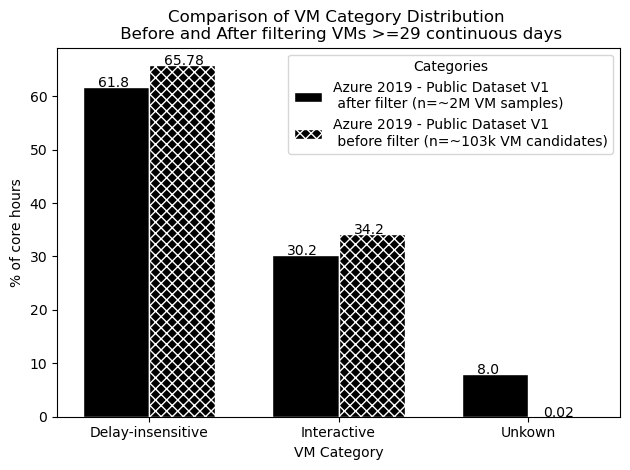

In [ ]:
dataset_after.loc[dataset_after['percentage'] == dataset_after.percentage[2], 'percentage'] = 0.02

#hatches =['..', 'xxx','..','ooo','xx']
#TraceLegend = "Azure 2019 - Public Dataset V2 - before filter"
#AzureLegend = "Azure 2019 - Public Dataset V2 - after filter"

TraceLegend_V1 = f"Azure 2019 - Public Dataset V1 \n before filter (n=~{display_most_valuable_digits(trace_dataframe_filtered.shape[0])} VM candidates)"
AzureLegend_V1 = f"Azure 2019 - Public Dataset V1 \n after filter (n=~{display_most_valuable_digits(trace_dataframe.shape[0])} VM samples)"

bar_width = 0.35
labels = dataset_before['vmcategory']
x = np.arange(len(labels))

bars_before = plt.bar(x - bar_width/2, dataset_before['percentage'], width=bar_width, label=AzureLegend_V1, color='k', edgecolor="w")
bars_after  = plt.bar(x + bar_width/2, dataset_after['percentage'],  width=bar_width, label=TraceLegend_V1, color='k', hatch=['xxx'], edgecolor="w")
#plt.bar(x - bar_width/4, dataset_before['percentage'], width=bar_width, label=AzureLegend_V2, color='b', edgecolor="w")
#plt.bar(x + bar_width/4, dataset_after['percentage'],  width=bar_width, label=TraceLegend_V2, color='b', hatch=['xxx'], edgecolor="w")

# access the bar attributes to place the text in the appropriate location
for bar in bars_before:
    yval = bar.get_height()
    plt.text(bar.get_x()+ 0.08, yval + .005, yval)

for bar in bars_after:
    yval = bar.get_height()
    plt.text(bar.get_x()+ 0.08, yval + .005, yval)


plt.xlabel('VM Category')
plt.ylabel('% of core hours')
plt.title('Comparison of VM Category Distribution \n Before and After filtering VMs >=29 continuous days')
plt.xticks(x, labels)
plt.legend(loc='best', title='Categories')

plt.tight_layout()
plt.show()

In [ ]:
dataset_after.loc[dataset_after['percentage'] == 0.5, 'percentage'] = 0
#result = pd.concat([dataset_after,dataset_before], axis=1, ignore_index=False, sort=True)
result = pd.concat([dataset_before,dataset_after], axis=1, ignore_index=False, sort=True)
del result['vmcategory']
result = result.T
result

,0,1,2
percentage,61.797833,30.200133,8.002034
percentage,65.780035,34.200403,0.019562


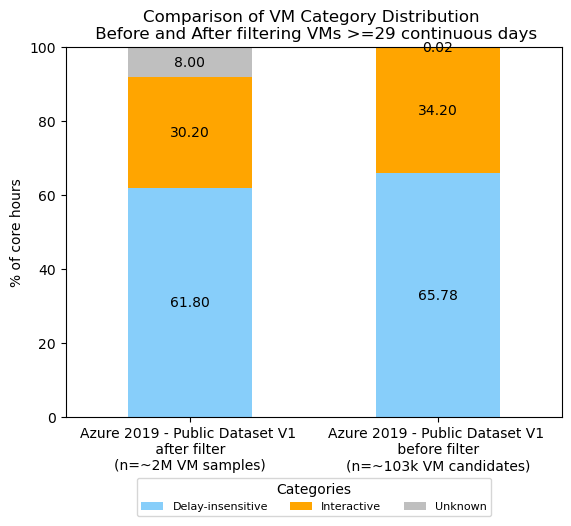

In [ ]:
#hatches =['..', 'xxx','..','ooo','xx']

ax = result.plot.bar(stacked=True,
                     #title='VM Category Distribution',
                     title='Comparison of VM Category Distribution \n Before and After filtering VMs >=29 continuous days',
                     color=['lightskyblue', 'orange', '0.75'],
                     ylim=(0, 100))

ax.set_ylabel('% of core hours')
#ax.set_xticklabels(["Azure 2019 - Public Dataset V2 \n after filter (n=250M VM samples)",
#                    "Azure 2019 - Public Dataset V2 \n before filter (n=180K VM samples)"],rotation=0)

ax.set_xticklabels([f"Azure 2019 - Public Dataset V1 \n after filter \n(n=~{display_most_valuable_digits(trace_dataframe.shape[0])} VM samples)",
                    f"Azure 2019 - Public Dataset V1 \n before filter \n(n=~{display_most_valuable_digits(trace_dataframe_filtered.shape[0])} VM candidates)"],rotation=0)

for i in range(result.shape[0]):
    for j in range(result.shape[1]):
        ax.text(i, result.iloc[i, :j+1].sum()-result.iloc[i, j]/2,
                f'{result.iloc[i, j]:.2f}',
                ha='center', va='center', color='black')

ax.legend(["Delay-insensitive", "Interactive", "Unknown"], loc='upper center', title='Categories', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

plt.show()